# URBAN FLOOD STRESS | Network Connectivity

Notebook reproducible para interpretar cómo está conectada la red vial de NYC.

Flujo:
- leer la red procesada `lion_metrics.gpkg`,
- construir un grafo no dirigido de conectividad,
- identificar componentes conectados, puentes y nodos de articulación,
- guardar una capa conectividad-enriquecida y tablas resumen,
- producir mapas y tablas breves para inspección rápida.

El diseño sigue la lógica de `ml4c-pro`:
- grafos basados en LION,
- conectividad como diagnóstico estructural,
- salida lista para análisis de resiliencia posterior.

In [1]:

from __future__ import annotations

import os
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MPLCONFIGDIR = Path('/tmp/matplotlib')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

try:
    import igraph as ig
except ModuleNotFoundError as exc:  # pragma: no cover - import guard
    raise RuntimeError(
        'Este notebook requiere `python-igraph`. Instala la dependencia antes de ejecutarlo.'
    ) from exc

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook fallback
    display = print

plt.style.use('seaborn-v0_8-whitegrid')


def find_project_root(start: Path | None = None) -> Path:
    """Return the repository root."""
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('No se encontro la raiz del proyecto.')


ROOT = find_project_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from project_name.utils import ensure_directory

LION_METRICS_PATH = ROOT / 'data/spatial/vector/streets/processed/lion_metrics.gpkg'
LION_NODE_METRICS_PATH = ROOT / 'data/spatial/vector/streets/processed/lion_node_metrics.csv'
BOUNDARY_PATH = ROOT / 'data/spatial/vector/nyc_borough_boundary/nybb.geojson'

OUTPUT_DIR = ensure_directory(ROOT / 'data/spatial/vector/streets/processed')
CONNECTIVITY_GPKG = OUTPUT_DIR / 'lion_connectivity.gpkg'
CONNECTIVITY_GEOJSON = OUTPUT_DIR / 'lion_connectivity.geojson'
CONNECTIVITY_NODES_CSV = OUTPUT_DIR / 'lion_connectivity_nodes.csv'
CONNECTIVITY_COMPONENTS_CSV = OUTPUT_DIR / 'lion_connectivity_components.csv'
CONNECTIVITY_SUMMARY_CSV = OUTPUT_DIR / 'lion_connectivity_summary.csv'

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)

print(ROOT)
print(LION_METRICS_PATH)
print(LION_NODE_METRICS_PATH)


/home/map10194/Documents/urban-flood-stress
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/streets/processed/lion_metrics.gpkg
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/streets/processed/lion_node_metrics.csv


In [2]:
def build_connectivity_graph(frame: pd.DataFrame) -> tuple[ig.Graph, pd.DataFrame]:
    """Build an undirected graph from processed LION segments."""
    working = frame.copy()
    if 'in_graph' in working.columns:
        working = working[working['in_graph'].fillna(False)].copy()

    working = working.dropna(subset=['u', 'v']).copy()
    working['u'] = pd.to_numeric(working['u'], errors='coerce').astype('Int64')
    working['v'] = pd.to_numeric(working['v'], errors='coerce').astype('Int64')
    working = working.dropna(subset=['u', 'v']).copy()
    working['u'] = working['u'].astype(int)
    working['v'] = working['v'].astype(int)
    working['edge_id'] = pd.to_numeric(working['edge_id'], errors='coerce').astype('Int64')
    working = working.dropna(subset=['edge_id']).copy()
    working['edge_id'] = working['edge_id'].astype(int)

    node_count = int(working[['u', 'v']].to_numpy().max()) + 1
    edges = list(working[['u', 'v']].itertuples(index=False, name=None))
    graph = ig.Graph(n=node_count, edges=edges, directed=False)
    graph.vs['node_id'] = list(range(node_count))
    graph.es['edge_id'] = working['edge_id'].tolist()
    if 'travel_time' in working.columns:
        graph.es['weight'] = pd.to_numeric(working['travel_time'], errors='coerce').fillna(1.0).tolist()
    elif 'length' in working.columns:
        graph.es['weight'] = pd.to_numeric(working['length'], errors='coerce').fillna(1.0).tolist()
    else:
        graph.es['weight'] = [1.0] * len(working)
    return graph, working


def compute_connectivity(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, ig.Graph]:
    """Compute component, bridge, and articulation summaries."""
    graph, edges = build_connectivity_graph(frame)
    components = graph.connected_components(mode='weak')
    membership = np.asarray(components.membership)
    component_sizes = np.asarray(components.sizes())
    largest_component_id = int(component_sizes.argmax())
    bridge_edge_indices = set(graph.bridges())
    articulation_nodes = set(graph.articulation_points())

    node_metrics = pd.read_csv(LION_NODE_METRICS_PATH) if LION_NODE_METRICS_PATH.exists() else pd.DataFrame({'node_id': graph.vs['node_id']})
    if 'node_id' not in node_metrics.columns:
        node_metrics['node_id'] = graph.vs['node_id']
    node_metrics = node_metrics.copy()
    node_metrics['node_id'] = pd.to_numeric(node_metrics['node_id'], errors='coerce').astype('Int64')
    node_metrics = node_metrics.dropna(subset=['node_id']).copy()
    node_metrics['node_id'] = node_metrics['node_id'].astype(int)
    node_metrics['component_id'] = node_metrics['node_id'].map(lambda node_id: int(membership[node_id]))
    node_metrics['component_size'] = node_metrics['component_id'].map(lambda cid: int(component_sizes[cid]))
    node_metrics['in_largest_component'] = node_metrics['component_id'].eq(largest_component_id)
    node_metrics['is_articulation_node'] = node_metrics['node_id'].isin(articulation_nodes)
    if 'total_degree' not in node_metrics.columns:
        node_metrics['total_degree'] = graph.degree(mode='all')

    edge_metrics = pd.DataFrame(
        {
            'edge_id': edges['edge_id'].to_numpy(),
            'u': edges['u'].to_numpy(),
            'v': edges['v'].to_numpy(),
            'component_id': [int(membership[u]) for u in edges['u']],
            'component_size': [int(component_sizes[membership[u]]) for u in edges['u']],
            'in_largest_component': [int(membership[u]) == largest_component_id for u in edges['u']],
            'is_bridge_segment': [idx in bridge_edge_indices for idx in range(len(edges))],
        }
    )

    segment_metrics = frame.merge(edge_metrics, on=['edge_id', 'u', 'v'], how='left', suffixes=('', '_connectivity'))
    if 'edge_betweenness' in segment_metrics.columns:
        segment_metrics['edge_betweenness'] = pd.to_numeric(segment_metrics['edge_betweenness'], errors='coerce')

    components_df = (
        edge_metrics.groupby('component_id', as_index=False)
        .agg(
            segment_count=('edge_id', 'size'),
            bridge_segments=('is_bridge_segment', 'sum'),
        )
        .merge(
            node_metrics.groupby('component_id', as_index=False)
            .agg(
                node_count=('node_id', 'size'),
                articulation_nodes=('is_articulation_node', 'sum'),
                mean_degree=('total_degree', 'mean'),
                mean_node_betweenness=('node_betweenness', 'mean') if 'node_betweenness' in node_metrics.columns else ('total_degree', 'mean'),
            ),
            on='component_id',
            how='outer',
        )
        .fillna(0)
    )
    components_df['is_largest_component'] = components_df['component_id'].eq(largest_component_id)
    components_df['segment_share'] = components_df['segment_count'] / components_df['segment_count'].sum()
    components_df['node_share'] = components_df['node_count'] / components_df['node_count'].sum()
    components_df = components_df.sort_values(['is_largest_component', 'segment_count'], ascending=[False, False]).reset_index(drop=True)

    summary = pd.DataFrame(
        {
            'metric': [
                'segments_total',
                'nodes_total',
                'weak_components_total',
                'largest_component_id',
                'largest_component_segments',
                'largest_component_share_pct',
                'bridge_segments_total',
                'bridge_segments_share_pct',
                'articulation_nodes_total',
                'articulation_nodes_share_pct',
            ],
            'value': [
                int(len(edges)),
                int(len(node_metrics)),
                int(len(component_sizes)),
                int(largest_component_id),
                int(components_df.loc[components_df['is_largest_component'], 'segment_count'].iloc[0]),
                round((components_df.loc[components_df['is_largest_component'], 'segment_count'].iloc[0] / len(edges)) * 100, 2),
                int(edge_metrics['is_bridge_segment'].sum()),
                round((edge_metrics['is_bridge_segment'].mean()) * 100, 2),
                int(node_metrics['is_articulation_node'].sum()),
                round((node_metrics['is_articulation_node'].mean()) * 100, 2),
            ],
        }
    )

    return segment_metrics, node_metrics, edge_metrics, components_df, summary, graph


In [3]:
if CONNECTIVITY_GPKG.exists() and CONNECTIVITY_NODES_CSV.exists() and CONNECTIVITY_COMPONENTS_CSV.exists():
    connectivity_segments = gpd.read_file(CONNECTIVITY_GPKG)
    connectivity_nodes = pd.read_csv(CONNECTIVITY_NODES_CSV)
    connectivity_components = pd.read_csv(CONNECTIVITY_COMPONENTS_CSV)
    connectivity_summary = pd.read_csv(CONNECTIVITY_SUMMARY_CSV)
    print('loaded cached connectivity outputs')
else:
    lion_metrics = gpd.read_file(LION_METRICS_PATH)
    connectivity_segments, connectivity_nodes, connectivity_edges, connectivity_components, connectivity_summary, graph = compute_connectivity(lion_metrics)

    connectivity_segments = gpd.GeoDataFrame(connectivity_segments, geometry='geometry', crs=lion_metrics.crs)
    connectivity_segments['connectivity_processed'] = True
    connectivity_segments.to_file(CONNECTIVITY_GPKG, driver='GPKG')
    connectivity_segments.to_file(CONNECTIVITY_GEOJSON, driver='GeoJSON')
    connectivity_nodes.to_csv(CONNECTIVITY_NODES_CSV, index=False)
    connectivity_components.to_csv(CONNECTIVITY_COMPONENTS_CSV, index=False)
    connectivity_summary.to_csv(CONNECTIVITY_SUMMARY_CSV, index=False)
    print('saved connectivity outputs')

print('segments:', len(connectivity_segments))
print('nodes:', len(connectivity_nodes))
print('components:', len(connectivity_components))
display(connectivity_summary)
display(connectivity_components.head(15))
display(connectivity_nodes[['node_id', 'component_id', 'component_size', 'is_articulation_node']].head(10))


saved connectivity outputs
segments: 196904
nodes: 134270
components: 661


,metric,value
0,segments_total,196904.00
1,nodes_total,134270.00
2,weak_components_total,661.00
3,largest_component_id,0.00
4,largest_component_segments,157383.00
5,largest_component_share_pct,79.93
6,bridge_segments_total,21447.00
7,bridge_segments_share_pct,10.89
8,articulation_nodes_total,21401.00
9,articulation_nodes_share_pct,15.94


,component_id,segment_count,bridge_segments,node_count,articulation_nodes,mean_degree,mean_node_betweenness,is_largest_component,segment_share,node_share
0,0,157383,8434,102370,8892,4.562821,2.849854e+07,True,0.799288,0.762419
1,224,23019,2936,16441,2962,4.909434,1.753717e+06,False,0.116905,0.122447
2,2,8753,5009,8253,5007,4.202593,2.186203e+06,False,0.044453,0.061466
3,464,855,62,460,61,7.378261,9.180693e+03,False,0.004342,0.003426
4,295,505,18,189,22,10.084656,2.143175e+03,False,0.002565,0.001408
5,34,397,77,332,79,4.457831,6.725536e+03,False,0.002016,0.002473
6,591,331,324,328,317,4.030488,2.546277e+04,False,0.001681,0.002443
7,289,134,134,135,132,3.940741,5.808659e+03,False,0.000681,0.001005
8,286,132,120,127,124,4.110236,5.064984e+03,False,0.000670,0.000946
9,409,127,111,119,113,4.201681,2.388277e+03,False,0.000645,0.000886


,node_id,component_id,component_size,is_articulation_node
0,0,0,102370,False
1,1,0,102370,False
2,2,0,102370,False
3,3,0,102370,False
4,4,0,102370,False
5,5,0,102370,False
6,6,0,102370,False
7,7,0,102370,False
8,8,0,102370,False
9,9,0,102370,False


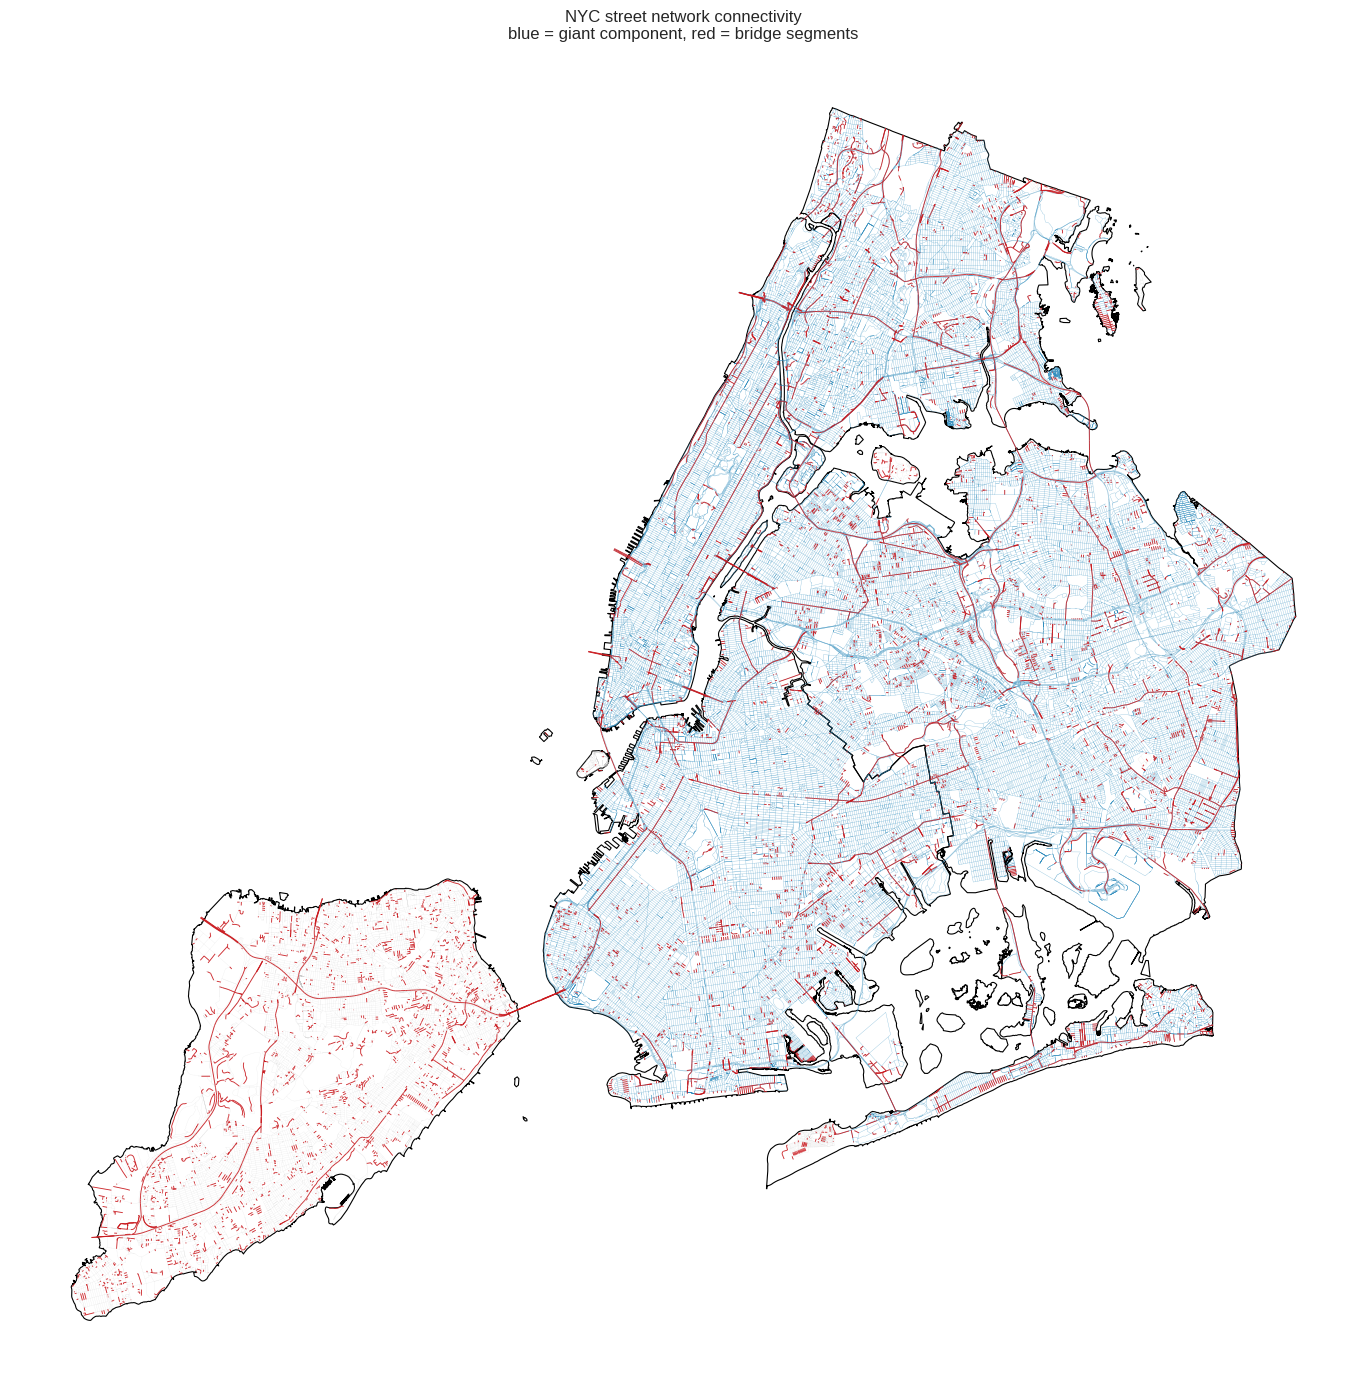

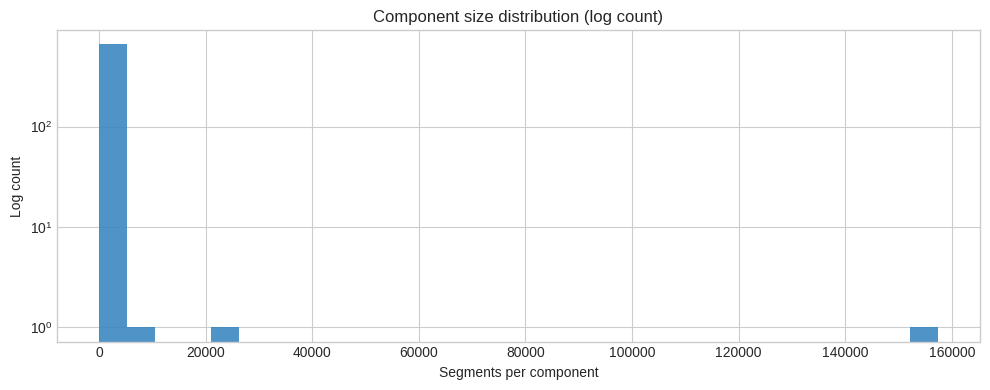

top bridge segments:


,edge_id,SegmentID,Street,component_id,component_size,edge_betweenness
171593,171593,0346109,ROOSEVELT IS BR PED & BIKE PATH,0,102370,37147734.0
164132,164132,0258891,ROOSEVELT IS BR PED & BIKE PATH,0,102370,36948385.0
96077,96077,0258880,ROOSEVELT IS BR PED & BIKE PATH,0,102370,36549675.0
96078,96078,0258881,ROOSEVELT IS BR PED & BIKE PATH,0,102370,36350314.0
94598,94598,0242341,PEDESTRIAN AND BIKE PATH LINK,0,102370,36150949.0
94599,94599,0242342,BIKE PATH,0,102370,35951580.0
29258,29258,0316823,CITY IS BRIDGE,0,102370,30567105.0
3816,3816,0107624,CITY IS BRIDGE,0,102370,29968650.0
167368,167368,0300578,TOTTEN AVENUE,0,102370,22784382.0
157156,157156,0117360,TOTTEN AVENUE,0,102370,22584745.0


In [4]:
boundary = gpd.read_file(BOUNDARY_PATH).to_crs(connectivity_segments.crs)
largest_component_id = int(connectivity_components.loc[connectivity_components['is_largest_component'], 'component_id'].iloc[0])

bridge_segments = connectivity_segments[connectivity_segments['is_bridge_segment'].fillna(False)].copy()
giant_component = connectivity_segments[connectivity_segments['component_id'] == largest_component_id].copy()
non_giant = connectivity_segments[connectivity_segments['component_id'] != largest_component_id].copy()

fig, ax = plt.subplots(figsize=(14, 14))
boundary.boundary.plot(ax=ax, color='black', linewidth=0.8)
non_giant.plot(ax=ax, color='#c7c7c7', linewidth=0.2, alpha=0.35)
giant_component.plot(ax=ax, color='#2b8cbe', linewidth=0.25, alpha=0.55)
if not bridge_segments.empty:
    bridge_segments.plot(ax=ax, color='#cb181d', linewidth=0.65, alpha=0.9)
ax.set_title('NYC street network connectivity\nblue = giant component, red = bridge segments')
ax.set_axis_off()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
connectivity_components['segment_count'].clip(lower=1).plot.hist(ax=ax, bins=30, color='#3182bd', alpha=0.85, log=True)
ax.set_title('Component size distribution (log count)')
ax.set_xlabel('Segments per component')
ax.set_ylabel('Log count')
plt.tight_layout()
plt.show()

print('top bridge segments:')
display(
    connectivity_segments.loc[connectivity_segments['is_bridge_segment'].fillna(False)]
    .sort_values(['edge_betweenness', 'component_size'], ascending=[False, False])
    .loc[:, ['edge_id', 'SegmentID', 'Street', 'component_id', 'component_size', 'edge_betweenness']]
    .head(20)
)
